# PINN 1D Heat Equation  (Neumann Boundary Condition)

**PDE:** $u_t = \alpha \, u_{xx}$, &nbsp; $x \in [0,1]$, &nbsp; $t \in [0,1]$

**Boundary conditions:**
- Left $x=0$: $\partial_x u(0,t) = q$ (constant heat flux applied)
- Right $x=1$: $\partial_x u(1,t) = 0$ (insulated — no heat escapes)

**Initial condition:** $u(x,0) = U_0$ (uniform temperature)

**Loss Function:** $\mathcal{L} = \mathcal{L}_{PDE} + \mathcal{L}_{BC} + \mathcal{L}_{IC} + \lambda_{data}\,\mathcal{L}_{data}$

## 1 · Imports and setup

In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 2 · Problem parameters

Edit these values to change the physics.

In [ ]:
ALPHA       = 0.1    # thermal diffusivity
FLUX        = -1.0   # heat flux at x=0 (negative = heat flowing INTO the rod)
U0          = 0.0    # uniform initial temperature  u(x,0) = U0
LAMBDA_DATA = 10.0   # weight on data loss term

# Training settings
N_EPOCHS  = 5_000
LR        = 1e-3
LAYERS    = [2, 128, 128, 128, 128, 1] # network architecture

# Collocation / constraint point counts
N_COL = 6_000   # interior PDE points
N_BC  = 200     # boundary points per side
N_IC  = 200     # initial condition points

# Data source
DATA_FILE = None
N_OBS_SYNTHETIC = 150 # number of synthetic observation points when no data file

## 3 · Neural network

In [3]:
class PINN(nn.Module):
    
    def __init__(self, layers: list):
        super().__init__()
        self.activation = nn.Tanh()
        self.net = nn.ModuleList(
            nn.Linear(a, b) for a, b in zip(layers[:-1], layers[1:])
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        h = torch.cat([x, t], dim=1)
        for layer in self.net[:-1]:
            h = self.activation(layer(h))
        return self.net[-1](h)

## 4 · Collocation & constraint points

In [4]:
def make_training_data(n_col=N_COL, n_bc=N_BC, n_ic=N_IC):
    
    # Interior collocation points
    x_col = torch.rand(n_col, 1, device=DEVICE, requires_grad=True)
    t_col = torch.rand(n_col, 1, device=DEVICE, requires_grad=True)

    # Left boundary x = 0
    x_bc_left = torch.zeros(n_bc, 1, device=DEVICE, requires_grad=True)
    t_bc_left = torch.rand(n_bc,  1, device=DEVICE)

    # Right boundary x = 1
    x_bc_right = torch.ones(n_bc, 1, device=DEVICE, requires_grad=True)
    t_bc_right = torch.rand(n_bc, 1, device=DEVICE)

    # Initial condition t = 0, u = U0 = 0
    x_ic = torch.rand(n_ic, 1, device=DEVICE)
    t_ic = torch.zeros(n_ic, 1, device=DEVICE)
    u_ic = torch.full((n_ic, 1), U0, device=DEVICE)

    return (
        (x_col, t_col),
        (x_bc_left, t_bc_left),
        (x_bc_right, t_bc_right),
        (x_ic, t_ic, u_ic)
    )

## 5 · External / observed data

Load data from CSV file or generate synthetic observations with a finite-difference reference solver.

In [5]:
def load_observed_data(filepath: str):
    """
    Load sensor measurements from a CSV with columns: x, t, u
    """
    data = np.loadtxt(filepath, delimiter=",", skiprows=1)
    if data.ndim == 1:
        data = data[np.newaxis, :]      # handle single-row file
    x_obs = torch.tensor(data[:, 0:1], dtype=torch.float32, device=DEVICE)
    t_obs = torch.tensor(data[:, 1:2], dtype=torch.float32, device=DEVICE)
    u_obs = torch.tensor(data[:, 2:3], dtype=torch.float32, device=DEVICE)
    print(f"Loaded {len(x_obs)} observations from '{filepath}'.")
    return x_obs, t_obs, u_obs


def make_synthetic_observations(n_obs: int = N_OBS_SYNTHETIC):
    
    print(f"No data file provided — generating {n_obs} synthetic observations via FD solver.")
    Nx   = 101
    x_fd = np.linspace(0, 1, Nx)
    dx   = x_fd[1] - x_fd[0]

    def rhs(t, u):
        """FD RHS with Neumann BCs via ghost nodes."""
        dudt = np.zeros_like(u)
        dudt[1:-1] = ALPHA * (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        # Left BC:  u_x(0,t) = FLUX
        u_ghost_left  = u[1] - 2 * dx * FLUX
        dudt[0]  = ALPHA * (u[1] - 2*u[0] + u_ghost_left) / dx**2
        # Right BC: u_x(1,t) = 0
        u_ghost_right = u[-2]
        dudt[-1] = ALPHA * (u_ghost_right - 2*u[-1] + u[-2]) / dx**2
        return dudt

    u_init = np.full(Nx, U0)
    sol    = solve_ivp(rhs, [0, 1], u_init, method="RK45",
                       t_eval=np.linspace(0, 1, 200), max_step=1e-3)

    # Sample random (x, t) pairs
    idx_t    = np.random.randint(0, sol.t.size, n_obs)
    idx_x    = np.random.randint(0, Nx,         n_obs)
    x_obs_np = x_fd[idx_x]
    t_obs_np = sol.t[idx_t]
    u_obs_np = sol.y[idx_x, idx_t]

    x_obs = torch.tensor(x_obs_np[:, None], dtype=torch.float32, device=DEVICE)
    t_obs = torch.tensor(t_obs_np[:, None], dtype=torch.float32, device=DEVICE)
    u_obs = torch.tensor(u_obs_np[:, None], dtype=torch.float32, device=DEVICE)
    return x_obs, t_obs, u_obs, sol

## 6 · PDE residual & boundary flux

In [6]:
def pde_residual(model, x, t):
    """Returns  u_t - (alpha * u_xx)  at every collocation point."""
    u    = model(x, t)
    u_t  = torch.autograd.grad(u,   t,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_x  = torch.autograd.grad(u,   x,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x,   grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_t - (ALPHA * u_xx)


def flux_at_boundary(model, x_bc, t_bc):
    """Returns du/dx at a boundary (x_bc must have requires_grad=True)."""
    u   = model(x_bc, t_bc)
    u_x = torch.autograd.grad(u, x_bc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    return u_x

## 7 · Loss function

In [7]:
def total_loss(model, col_data, bc_left_data, bc_right_data, ic_data, obs_data):
    x_col,  t_col          = col_data
    x_bc_l, t_bc_l         = bc_left_data
    x_bc_r, t_bc_r         = bc_right_data
    x_ic,   t_ic,   u_ic   = ic_data
    x_obs,  t_obs,  u_obs  = obs_data

    # PDE residual loss
    loss_pde  = torch.mean(pde_residual(model, x_col, t_col) ** 2)

    # Boundary condition loss
    loss_bc_l = torch.mean((flux_at_boundary(model, x_bc_l, t_bc_l) - FLUX) ** 2)
    loss_bc_r = torch.mean(flux_at_boundary(model, x_bc_r, t_bc_r) ** 2)
    loss_bc   = loss_bc_l + loss_bc_r

    # Initial condition loss
    loss_ic   = torch.mean((model(x_ic, t_ic) - u_ic) ** 2)

    # Data loss
    loss_data = torch.mean((model(x_obs, t_obs) - u_obs) ** 2)

    total = loss_pde + loss_bc + loss_ic + LAMBDA_DATA * loss_data
    return total, loss_pde, loss_bc, loss_ic, loss_data

## 8 · Training

In [8]:
def train(obs_data, n_epochs=N_EPOCHS, lr=LR, layers=None):
    if layers is None:
        layers = LAYERS

    model     = PINN(layers).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, total_steps=n_epochs, pct_start=0.1)

    col_data, bc_left_data, bc_right_data, ic_data = make_training_data()

    history = {"total": [], "pde": [], "bc": [], "ic": [], "data": []}

    header = f"{'Epoch':>8}  {'Total':>12}  {'PDE':>12}  {'BC':>12}  {'IC':>12}  {'Data':>12}"
    print(f"\n{header}")
    print("-" * len(header))

    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()
        loss, l_pde, l_bc, l_ic, l_data = total_loss(
            model, col_data, bc_left_data, bc_right_data, ic_data, obs_data)
        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["pde"].append(l_pde.item())
        history["bc"].append(l_bc.item())
        history["ic"].append(l_ic.item())
        history["data"].append(l_data.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"{epoch:>8}  {loss.item():>12.2e}  {l_pde.item():>12.2e}"
                f"  {l_bc.item():>12.2e}  {l_ic.item():>12.2e}  {l_data.item():>12.2e}")

    print("\nTraining complete.")
    return model, history

## 9 · Load data & run training

In [9]:
start = time.time()

# Load or generate observations
fd_solution = None

if DATA_FILE:
    obs_data = load_observed_data(DATA_FILE)
else:
    *obs_list, fd_solution = make_synthetic_observations(N_OBS_SYNTHETIC)
    obs_data = tuple(obs_list)

t0 = time.time()
print(f"Data ready in {t0 - start:.2f}s")

# Train
model, history = train(obs_data)

t1 = time.time()
print(f"Training finished in {t1 - t0:.2f}s")

No data file provided — generating 150 synthetic observations via FD solver.
Data ready in 0.15s

   Epoch         Total           PDE            BC            IC          Data
------------------------------------------------------------------------------
       1      1.27e+00      3.57e-03      1.17e+00      2.38e-03      9.01e-03
     500      5.46e-03      1.23e-03      1.23e-03      7.90e-04      2.20e-04
    1000      2.28e-03      5.82e-04      3.46e-04      5.10e-04      8.36e-05
    1500      1.73e-03      4.32e-04      1.83e-04      4.53e-04      6.60e-05
    2000      1.28e-03      4.55e-04      1.04e-04      3.15e-04      4.05e-05
    2500      1.05e-03      3.46e-04      9.26e-05      2.74e-04      3.41e-05
    3000      7.47e-04      2.85e-04      8.55e-05      1.80e-04      1.96e-05
    3500      5.64e-04      2.23e-04      6.32e-05      1.40e-04      1.38e-05
    4000      5.16e-04      1.61e-04      6.72e-05      1.21e-04      1.67e-05
    4500      2.97e-04      1.12e

## 10 · Evaluation & plots

Relative L2 error vs FD reference: 1.3989e-02


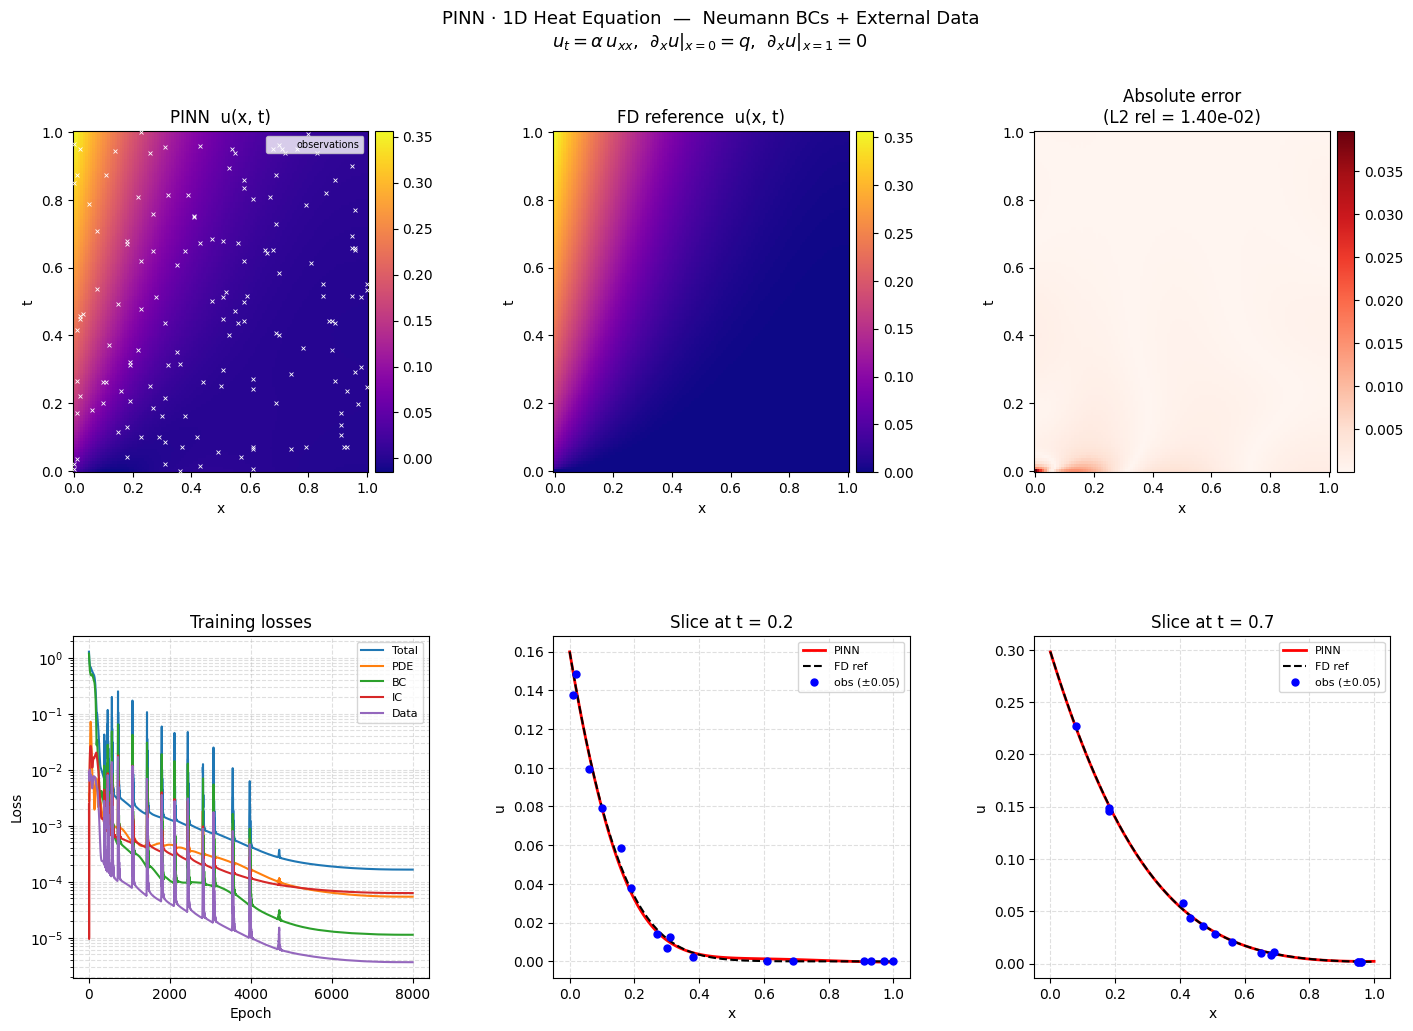

Plot saved → pinn_heat_neumann.png
Plotting finished in 2.53s


In [10]:
@torch.no_grad()
def evaluate_and_plot(model, history, obs_data, fd_solution=None):
    Nx, Nt = 120, 120
    x_np   = np.linspace(0, 1, Nx)
    t_np   = np.linspace(0, 1, Nt)
    XX, TT = np.meshgrid(x_np, t_np)

    x_flat = torch.tensor(XX.ravel(), dtype=torch.float32, device=DEVICE).unsqueeze(1)
    t_flat = torch.tensor(TT.ravel(), dtype=torch.float32, device=DEVICE).unsqueeze(1)
    u_pred = model(x_flat, t_flat).cpu().numpy().reshape(Nt, Nx)

    x_obs_np = obs_data[0].cpu().numpy().ravel()
    t_obs_np = obs_data[1].cpu().numpy().ravel()
    u_obs_np = obs_data[2].cpu().numpy().ravel()

    fig = plt.figure(figsize=(17, 11))
    fig.suptitle(
        "PINN · 1D Heat Equation  —  Neumann BCs + External Data\n"
        r"$u_t = \alpha\,u_{xx}$,  $\partial_x u|_{x=0}=q$,  $\partial_x u|_{x=1}=0$",
        fontsize=13, y=0.99,
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

    def heatmap(ax, data, title, cmap, scatter=False):
        im = ax.pcolormesh(x_np, t_np, data, cmap=cmap, shading="auto")
        plt.colorbar(im, ax=ax, pad=0.02)
        if scatter:
            ax.scatter(x_obs_np, t_obs_np, c="white", s=8, marker="x",
                       linewidths=0.6, label="observations", zorder=3)
            ax.legend(fontsize=7, loc="upper right")
        ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title)

    heatmap(fig.add_subplot(gs[0, 0]), u_pred, "PINN  u(x, t)", "plasma", scatter=True)

    if fd_solution is not None:
        from scipy.interpolate import RegularGridInterpolator
        x_fd   = np.linspace(0, 1, fd_solution.y.shape[0])
        interp = RegularGridInterpolator(
            (x_fd, fd_solution.t), fd_solution.y,
            method="linear", bounds_error=False, fill_value=None,
        )
        u_ref   = interp(np.column_stack([XX.ravel(), TT.ravel()])).reshape(Nt, Nx)
        u_error = np.abs(u_pred - u_ref)
        l2_err  = np.linalg.norm(u_error) / (np.linalg.norm(u_ref) + 1e-12)
        print(f"Relative L2 error vs FD reference: {l2_err:.4e}")
        heatmap(fig.add_subplot(gs[0, 1]), u_ref,   "FD reference  u(x, t)", "plasma")
        heatmap(fig.add_subplot(gs[0, 2]), u_error,
                f"Absolute error\n(L2 rel = {l2_err:.2e})", "Reds")
    else:
        ax = fig.add_subplot(gs[0, 1])
        ax.text(0.5, 0.5, "Provide a CSV file\nto compare against data",
                ha="center", va="center", transform=ax.transAxes)
        fig.add_subplot(gs[0, 2]).axis("off")

    # Loss curves
    ax_loss  = fig.add_subplot(gs[1, 0])
    epochs_v = np.arange(1, len(history["total"]) + 1)
    for key, lbl in [("total","Total"),("pde","PDE"),("bc","BC"),("ic","IC"),("data","Data")]:
        ax_loss.semilogy(epochs_v, history[key], label=lbl)
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.set_title("Training losses"); ax_loss.legend(fontsize=8)
    ax_loss.grid(True, which="both", ls="--", alpha=0.4)

    # Spatial slices
    for col_idx, t_val in enumerate([0.2, 0.7], start=1):
        t_idx = np.argmin(np.abs(t_np - t_val))
        ax    = fig.add_subplot(gs[1, col_idx])
        ax.plot(x_np, u_pred[t_idx], "r-", lw=2, label="PINN")
        if fd_solution is not None:
            t_fd_idx = np.argmin(np.abs(fd_solution.t - t_val))
            ax.plot(np.linspace(0, 1, fd_solution.y.shape[0]),
                    fd_solution.y[:, t_fd_idx], "k--", lw=1.5, label="FD ref")
        mask = np.abs(t_obs_np - t_val) < 0.05
        if mask.any():
            ax.scatter(x_obs_np[mask], u_obs_np[mask],
                       c="blue", s=25, zorder=5, label="obs (±0.05)")
        ax.set_xlabel("x"); ax.set_ylabel("u")
        ax.set_title(f"Slice at t = {t_val}")
        ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.4)

    plt.savefig("pinn_heat_neumann.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved → pinn_heat_neumann.png")


evaluate_and_plot(model, history, obs_data, fd_solution)

t2 = time.time()
print(f"Plotting finished in {t2 - t1:.2f}s")

## 11 · Plot heat distribution at a specific time

Run this cell after training. Set `t_query` to any value in `[0, 1]` and re-run to update the plot.

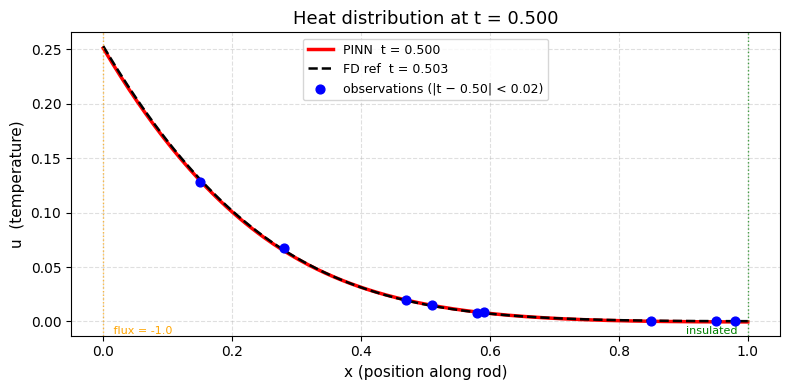

Saved → heat_at_t0.500.png


In [11]:
@torch.no_grad()
def plot_at_time(model, t_query: float, obs_data=None, fd_solution=None, Nx: int = 300):
    
    # Plot the PINN heat distribution u(x, t_query) across the rod.
    if not (0.0 <= t_query <= 1.0):
        raise ValueError(f"t_query must be in [0, 1], got {t_query}")

    # Evaluate model across the rod at t = t_query
    x_np  = np.linspace(0, 1, Nx)
    x_ten = torch.tensor(x_np[:, None], dtype=torch.float32, device=DEVICE)
    t_ten = torch.full((Nx, 1), t_query, dtype=torch.float32, device=DEVICE)
    u_np  = model(x_ten, t_ten).cpu().numpy().ravel()

    fig, ax = plt.subplots(figsize=(8, 4))

    # PINN prediction
    ax.plot(x_np, u_np, "r-", lw=2.5, label=f"PINN  t = {t_query:.3f}")

    # FD reference (if available)
    if fd_solution is not None:
        t_fd_idx = np.argmin(np.abs(fd_solution.t - t_query))
        t_fd_actual = fd_solution.t[t_fd_idx]
        x_fd = np.linspace(0, 1, fd_solution.y.shape[0])
        ax.plot(x_fd, fd_solution.y[:, t_fd_idx], "k--", lw=1.8,
                label=f"FD ref  t = {t_fd_actual:.3f}")

    # Nearby observations (within ±tolerance in time)
    if obs_data is not None:
        x_obs_np = obs_data[0].cpu().numpy().ravel()
        t_obs_np = obs_data[1].cpu().numpy().ravel()
        u_obs_np = obs_data[2].cpu().numpy().ravel()
        tolerance = 0.02   # show observations within ±0.02 of t_query
        mask = np.abs(t_obs_np - t_query) < tolerance
        if mask.any():
            ax.scatter(x_obs_np[mask], u_obs_np[mask],
                       c="blue", s=40, zorder=5,
                       label=f"observations (|t − {t_query:.2f}| < {tolerance})")
        else:
            print(f"No observations within ±{tolerance} of t = {t_query:.3f}")

    ax.axvline(x=0, color="orange", lw=1, ls=":", alpha=0.7)
    ax.axvline(x=1, color="green",  lw=1, ls=":", alpha=0.7)
    ax.text(0.01, ax.get_ylim()[0], f" flux = {FLUX}",
            color="orange", fontsize=8, va="bottom")
    ax.text(0.99, ax.get_ylim()[0], "insulated ",
            color="green",  fontsize=8, va="bottom", ha="right")

    ax.set_xlabel("x (position along rod)", fontsize=11)
    ax.set_ylabel("u  (temperature)",       fontsize=11)
    ax.set_title(f"Heat distribution at t = {t_query:.3f}", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, ls="--", alpha=0.4)
    plt.tight_layout()

    fname = f"heat_at_t{t_query:.3f}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")


# Change t_query to any value in [0, 1] and re-run this cell
t_query = 0.5

plot_at_time(model, t_query, obs_data=obs_data, fd_solution=fd_solution)

## 12 · Total runtime

In [12]:
elapsed = time.time() - start
hours   = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = elapsed % 60
print(f"Total runtime: {hours:02d}h {minutes:02d}m {seconds:05.2f}s")

Total runtime: 00h 30m 55.18s
